In [1]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

In [2]:
!pip install networkx

In [3]:
!pip install -q 'graphrag>=3.0.0'

In [73]:
import networkx

In [4]:
from pathlib import Path
import os
# from dotenv import load_dotenv
# load_dotenv()

from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
llm = ChatOpenAI(model="gpt-4o-mini")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/data/council.txt")
text = DATA_PATH.read_text(encoding="utf-8")

/tmp/ipykernel_5343/3547732403.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [5]:
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ragtest_0612")

In [6]:
!graphrag init --root {PROJECT_ROOT} --force

Specify the default chat model to use [gpt-4.1]: 

In [8]:
!graphrag init \
  --root "$PROJECT_ROOT" \
  --force \
  --model gpt-4.1-mini \
  --embedding text-embedding-3-small

In [9]:
import yaml
settings_path = PROJECT_ROOT / "settings.yaml"
s = yaml.safe_load(settings_path.read_text())

In [10]:
s['models']['default_chat_model']['model'] = "gpt-4o-mini"

KeyError: 'models'

In [ ]:
s['models']['default_embedding_model']['model'] = "text-embedding-3-small"

In [11]:
settings_path.write_text(yaml.safe_dump(s, allow_unicode = True, sort_keys = False))

2507

In [14]:
def list_project_files(root):
  out = {}
  for p in sorted(root.rglob('*')):
    rel = str(p.relative_to(root))
    out[rel] = -1 if p.is_dir() else p.stat().st_size

  return out

In [15]:
files = list_project_files(PROJECT_ROOT)
for path, sz in files.items():
  category = "dir" if sz == -1 else "file"
  size_str = "DIR" if sz == -1 else f"{sz}B"
  print(f" {category} {path} {size_str}")

 file .env 27B
 dir input DIR
 dir prompts DIR
 file prompts/basic_search_system_prompt.txt 2750B
 file prompts/community_report_graph.txt 8856B
 file prompts/community_report_text.txt 7804B
 file prompts/drift_reduce_prompt.txt 2798B
 file prompts/drift_search_system_prompt.txt 3288B
 file prompts/extract_claims.txt 4612B
 file prompts/extract_graph.txt 6483B
 file prompts/global_search_knowledge_system_prompt.txt 249B
 file prompts/global_search_map_system_prompt.txt 3970B
 file prompts/global_search_reduce_system_prompt.txt 3707B
 file prompts/local_search_system_prompt.txt 2551B
 file prompts/question_gen_system_prompt.txt 786B
 file prompts/summarize_descriptions.txt 733B
 file settings.yaml 2507B


In [16]:
env_path = PROJECT_ROOT / ".env"
api_key = os.getenv("OPENAI_API_KEY", '')

In [19]:
api_key[:10]

'sk-proj-__'

In [20]:
env_path.write_text(f"GRAPHRAG_API_KEY = {api_key}\n")

184

In [21]:
# 입력데이터 추가
# DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/data/council.txt")

In [22]:
# 'data/council.txt'
import shutil

input_dir = PROJECT_ROOT / 'input'
input_dir.mkdir(exist_ok = True)
src = DATA_PATH
dst = input_dir / 'council.txt'
shutil.copy(src, dst)

PosixPath('/content/drive/MyDrive/Colab Notebooks/ragtest_0612/input/council.txt')

In [24]:
def prepare_input(root: Path, source_files: list):
    input_dir = root / "input"
    input_dir.mkdir(exist_ok=True)

    copied = []
    total = 0

    for src in source_files:
        src = Path(src)
        dst = input_dir / src.name
        shutil.copy(src, dst)
        copied.append(src.name)
        total += dst.stat().st_size

    return copied

In [25]:
# corpus -> Graph indexing
# 1. 코퍼스 청킹
# 2. entity, relation 추출
# 3. merge 수행, entity 정규화 (센 -> 모리카이 센) 등, 동의어 변환
# 4. 커뮤니티
# 5. 커뮤니티별 report
# 6. 임베딩
# 7. pkl

In [27]:
import time

t0 = time.time()
!graphrag index --root "{PROJECT_ROOT}"
print(f"{(time.time() - t0)/60} min")

11:36:37 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'
11:36:38 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'
Starting pipeline with workflows: load_input_documents, create_base_text_units, create_final_documents, extract_graph, finalize_graph, extract_covariates, create_communities, create_final_text_units, create_community_reports, generate_text_embeddings
Starting workflow: load_input_documents

Workflow complete: load_input_documents
Starting workflow: create_base_text_units
  1 / 1 ............................................................................................
Workflow complete: create_base_text_units
Starting workflow: create_final_documents

Workflow complete: create_final

In [29]:
# 두번째 실행하면 캐싱때문에 속도가 빨라짐

In [28]:
import time

t0 = time.time()
!graphrag index --root "{PROJECT_ROOT}"
print(f"{(time.time() - t0)/60} min")

11:39:08 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'
11:39:08 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'
Starting pipeline with workflows: load_input_documents, create_base_text_units, create_final_documents, extract_graph, finalize_graph, extract_covariates, create_communities, create_final_text_units, create_community_reports, generate_text_embeddings
Starting workflow: load_input_documents

Workflow complete: load_input_documents
Starting workflow: create_base_text_units
  1 / 1 ............................................................................................
Workflow complete: create_base_text_units
Starting workflow: create_final_documents

Workflow complete: create_final

### 글리닝(gleaning)
- 무작정 많이한다고 좋아지진 않음

In [55]:
s = yaml.safe_load(sp.read_text())
print(list(s.keys()))  # ['completion_models', 'embedding_models', ...] 형태일 가능성이 높음

NameError: name 'sp' is not defined

In [52]:
# def setup_project_with_gleaning(suffix, n_gleanings):
#   root = Path(f"ragtest_0612_g{suffix}")
#   root.mkdir(exist_ok = True)
#   if not (root / 'settings.yaml').exists():
#     os.system(f"graphrag init --root {root} --force")
#   sp = root / "settings.yaml"
#   s = yaml.safe_load(sp.read_text())
#   s['models']['default_chat_model']['model'] = 'gpt-4o-mini'
#   s['models']['default_embedding_model']['model'] = 'text-embedding-3-small'
#   s.setdefault('extract_graph', {})['max_gleanings'] = n_gleanings

#   sp.write_text(yaml.safe_dump(s, allow_unicode = True, sort_keys = False))
#   (root / '.env').write_text((PROJECT_ROOT / '.env').read_text())

#   (root / 'input').mkdir(exist_ok = True)
#   for txt in input_dir.glob('*.txt'):
#     shutil.copy(txt, root / 'input' / txt.name)

#   return root

In [58]:
def setup_project_with_gleaning(suffix, n_gleanings):
    root = Path(f"ragtest_0612_g{suffix}")
    root.mkdir(exist_ok=True)

    if not (root / "settings.yaml").exists():
        os.system(f"graphrag init --root {root} --force")

    sp = root / "settings.yaml"
    s = yaml.safe_load(sp.read_text())

    # 디버깅: 실제 top-level 키 확인
    print("YAML top-level keys:", list(s.keys()))

    # ---------- 모델 설정 ----------
    if "completion_models" in s and "embedding_models" in s:
        # 최신 스키마
        s["completion_models"]["default_completion_model"]["model"] = "gpt-4o-mini"
        s["embedding_models"]["default_embedding_model"]["model"] = "text-embedding-3-small"
        s["extract_graph"]["completion_model_id"] = "default_completion_model"
    elif "models" in s:
        # 구버전 스키마
        s["models"]["default_chat_model"]["model"] = "gpt-4o-mini"
        s["models"]["default_embedding_model"]["model"] = "text-embedding-3-small"
    else:
        raise RuntimeError("알 수 없는 settings.yaml 구조입니다. print(s.keys()) 결과를 확인하세요.")

    # ---------- extract_graph ----------
    s.setdefault("extract_graph", {})["max_gleanings"] = n_gleanings

    sp.write_text(yaml.safe_dump(s, allow_unicode=True, sort_keys=False))

    (root / ".env").write_text((PROJECT_ROOT / ".env").read_text())
    (root / "input").mkdir(exist_ok=True)
    for txt in input_dir.glob("*.txt"):
        shutil.copy(txt, root / "input" / txt.name)

    return root

In [50]:
import subprocess

In [59]:
import pandas as pd
gleaning_runs = []
for label, n in [("0", 0), ("2", 2)]:
  r = setup_project_with_gleaning(label, n) # -> ragtest_0612_g0
  t0 = time.time()
  os.system(f"graphrag index --root {r}")
  dt = time.time() - t0
  ent_count = len(pd.read_parquet (r/ 'output' / 'entities.parquet')) if (r / 'output' / 'entities.parquet').exists() else None # parquet 파일들? json과 유사, 빅데이터 처리 시스템에서 데이터를 효율적으로 저장하기 위한 데이터 포멧
  rel_count = len(pd.read_parquet (r/ 'output' / 'relationships.parquet')) if (r / 'output' / 'relationships.parquet').exists() else None
  gleaning_runs.append({'gleaning' : n, 'root': r, 'elapsed_s': dt, 'entities': ent_count, 'relationships':rel_count})

YAML top-level keys: ['completion_models', 'embedding_models', 'input', 'chunking', 'input_storage', 'output_storage', 'reporting', 'cache', 'vector_store', 'embed_text', 'extract_graph', 'summarize_descriptions', 'extract_graph_nlp', 'cluster_graph', 'extract_claims', 'community_reports', 'snapshots', 'local_search', 'global_search', 'drift_search', 'basic_search']
YAML top-level keys: ['completion_models', 'embedding_models', 'input', 'chunking', 'input_storage', 'output_storage', 'reporting', 'cache', 'vector_store', 'embed_text', 'extract_graph', 'summarize_descriptions', 'extract_graph_nlp', 'cluster_graph', 'extract_claims', 'community_reports', 'snapshots', 'local_search', 'global_search', 'drift_search', 'basic_search']


In [44]:
gleaning_runs

[{'gleaning': 0,
  'root': PosixPath('/content/ragtest_0612_g0'),
  'elapsed_s': 64.36457824707031,
  'entities': 18,
  'relationships': 14},
 {'gleaning': 2,
  'root': PosixPath('/content/ragtest_0612_g2'),
  'elapsed_s': 55.55685758590698,
  'entities': 21,
  'relationships': 19}]

In [60]:
def compare_gleaning(gleaning_runs):
    print(f"{'gleaning':<10}{'entities':>10}{'relations':>12}{'time(s)':>12}")

    for r in gleaning_runs:
        t = f"{r['elapsed_s']:.1f}" if r.get("elapsed_s") is not None else "(cached)"

        print(
            f"{r['gleaning']:<10}"
            f"{r['entities']:>10}"
            f"{r['relationships']:>12}"
            f"{t:>12}"
        )

In [56]:
def load_artifacts(root):
  output_dir = root/"output"
  out = {}
  for pq in sorted(output_dir.glob('*.parquet')):
    out[pq.stem] = pd.read_parquet(pq)

  return out

In [57]:
load_artifacts(PROJECT_ROOT)

{'communities':                                      id  human_readable_id  community  level  \
 0  b417fa95-9a7c-41f0-aef0-b9d723629423                  0          0      0   
 1  ce7459c9-fb5f-4e7f-bc7e-d6cd0572d910                  1          1      0   
 2  9e2b2981-529e-49ac-a51c-7a101f0e2b30                  2          2      0   
 3  048a8d7e-9e20-44d6-bb09-9e8f3609bba5                  3          3      0   
 
    parent children        title  \
 0      -1       []  Community 0   
 1      -1       []  Community 1   
 2      -1       []  Community 2   
 3      -1       []  Community 3   
 
                                           entity_ids  \
 0  [f9cb17e1-e964-4aed-9f70-1b2f61c65e34, 946c822...   
 1  [215238dd-814e-4caa-a0ee-820e1f981329, 0bcef44...   
 2  [e53a7f52-98de-4e8b-aea7-80ef7a2cbf42, d1df8b3...   
 3  [6f8d7a13-befe-446a-98a0-d8056ed2d951, 5438b03...   
 
                                     relationship_ids  \
 0  [0077d0b6-0db0-41bb-9352-3eee0e5ac354, 28dfe7d..

In [61]:
for name, df in load_artifacts(PROJECT_ROOT).items():
  print(f" {name} shape = {df.shape}, cols = {list(df.columns)}")

 communities shape = (4, 12), cols = ['id', 'human_readable_id', 'community', 'level', 'parent', 'children', 'title', 'entity_ids', 'relationship_ids', 'text_unit_ids', 'period', 'size']
 community_reports shape = (4, 15), cols = ['id', 'human_readable_id', 'community', 'level', 'parent', 'children', 'title', 'summary', 'full_content', 'rank', 'rating_explanation', 'findings', 'full_content_json', 'period', 'size']
 documents shape = (1, 7), cols = ['id', 'human_readable_id', 'title', 'text', 'text_unit_ids', 'creation_date', 'raw_data']
 entities shape = (27, 8), cols = ['id', 'human_readable_id', 'title', 'type', 'description', 'text_unit_ids', 'frequency', 'degree']
 relationships shape = (31, 8), cols = ['id', 'human_readable_id', 'source', 'target', 'description', 'weight', 'combined_degree', 'text_unit_ids']
 text_units shape = (2, 8), cols = ['id', 'human_readable_id', 'text', 'n_tokens', 'document_id', 'entity_ids', 'relationship_ids', 'covariate_ids']


In [66]:
def top_entities(arts, k=5):
    df = arts['entities'].copy()
    sort_col = 'degree'
    df = df.sort_values(sort_col, ascending = False).head(k)
    out = []
    for _, row in df.iterrows():
      out.append({
          'title' : row.get('title', ''),
          'type' : row.get('type', ''),
          sort_col : int(row.get(sort_col, 0)),
          'description_short' : str(row.get('description', ''))[:100]
      })
    return out

In [67]:
arts = load_artifacts(PROJECT_ROOT)

In [68]:
top_entities(arts)

[{'title': '눌마리 연구 위원회',
  'type': 'ORGANIZATION',
  'degree': 7,
  'description_short': '눌마리 연구 위원회는 오브루리 축제에 매년 참석하여 폐회식에서 다음 해 연구 방향을 발표하는 위원들로 구성된 공식 기구이다. 이 위원회는 콰빅스, 타즈렌, 브렌술 세 기관 간 자금'},
 {'title': '타즈렌 연구소',
  'type': 'ORGANIZATION',
  'degree': 5,
  'description_short': '타즈렌 연구소는 1992년 눌마리 서쪽 해안 마을에 해양 기록학자 리네아 오보스트가 설립한 연구 기관으로, 드리파 아키텍처라는 조류 주기 기반 업데이트 방식을 개발했다'},
 {'title': '콰빅스 연구소',
  'type': 'ORGANIZATION',
  'degree': 4,
  'description_short': '콰빅스 연구소는 1987년 눌마리 섬에 모리카이 센이 설립한 연구 기관으로, 대표 프로젝트는 기호 추론 시스템인 벨트란 사고 엔진이며 눌마리 연구 위원회의 주요 후원 기관 중 하나'},
 {'title': '노라셋 엔지니어링 그룹',
  'type': 'ORGANIZATION',
  'degree': 4,
  'description_short': '노라셋 엔지니어링 그룹은 눌마리 남쪽 항만 지역의 민간 하드웨어 컨소시엄으로 2003년에 해양 건축가 여러 명이 모여 설립한 회사이다. 자체 소프트웨어나 논문을 출판하지 않는 순수'},
 {'title': '벨트란 사고 엔진',
  'type': 'ORGANIZATION',
  'degree': 3,
  'description_short': '벨트란 사고 엔진은 눌마리 전역의 여러 기호 추론 시스템에 전력을 공급하는 사고 엔진으로, 콰빅스 연구소의 대표적인 기호 추론 시스템 프로젝트이다. 이 엔진은 노라셋 엔지니어링 그'}]

In [69]:
reports_df = arts['community_reports']

In [70]:
reports_df

,id,human_readable_id,community,level,parent,children,title,summary,full_content,rank,rating_explanation,findings,full_content_json,period,size
0,d1d0f201921971fd3a5dc9bed9692d90ae80b0ff555e7a...,0,0,0,-1,[],눌마리 기호 추론 시스템과 노라셋 엔지니어링 그룹 커뮤니티,이 커뮤니티는 눌마리 섬과 그 남쪽 항만 지역을 중심으로 형성된 연구 및 하드웨어 ...,# 눌마리 기호 추론 시스템과 노라셋 엔지니어링 그룹 커뮤니티\n\n이 커뮤니티는 ...,6.5,"눌마리 지역 내 중요한 연구 및 기술 인프라를 중심으로 구성된 커뮤니티로, 지역 내...",[{'explanation': '벨트란 사고 엔진은 눌마리 전역 여러 기호 추론 시...,"{\n ""title"": ""눌마리 기호 추론 시스템과 노라셋 엔지니어링 그룹 커...",2026-06-12,6
1,c8b370ac1be4d4ceb09fc3939f6edc7f7eddea08b24761...,1,1,0,-1,[],눌마리 연구 위원회와 눌마리 섬 연구 기관 네트워크,"이 커뮤니티는 눌마리 섬을 중심으로 콰빅스 연구소, 브렌술 아카데미 및 눌마리 연구...",# 눌마리 연구 위원회와 눌마리 섬 연구 기관 네트워크\n\n이 커뮤니티는 눌마리 ...,6.5,이 커뮤니티는 다수의 연구 기관과 공식 위원회가 협력하여 연구 개발 및 자원 조정을...,"[{'explanation': '눌마리 연구 위원회는 콰빅스 연구소, 타즈렌, 브렌...","{\n ""title"": ""눌마리 연구 위원회와 눌마리 섬 연구 기관 네트워크""...",2026-06-12,8
2,f549d3794b116606d7137dd8a13870e07b9a74f644ccf2...,2,2,0,-1,[],코바쉬 연구소와 파리타 대학교 AI 연구 커뮤니티,"이 커뮤니티는 옌라 톨름이 소장으로 있는 코바쉬 연구소와, 해당 연구소의 대표 AI...",# 코바쉬 연구소와 파리타 대학교 AI 연구 커뮤니티\n\n이 커뮤니티는 옌라 톨름...,6.5,본 커뮤니티는 지역 AI 연구 및 기술 개발에서 중대한 경쟁과 협력 구조를 갖추고 ...,[{'explanation': '코바쉬 연구소는 2001년에 눌마리 북부에 설립된 ...,"{\n ""title"": ""코바쉬 연구소와 파리타 대학교 AI 연구 커뮤니티"",...",2026-06-12,6
3,1c7be9925e056795f507f59326b1eaf33577c1b59948c2...,3,3,0,-1,[],타즈렌 연구소 and 해양학 Community in 눌마리 서쪽 해안 마을,"This community centers around 타즈렌 연구소, a resea...",# 타즈렌 연구소 and 해양학 Community in 눌마리 서쪽 해안 마을\n\...,6.5,The community exhibits moderate impact severit...,"[{'explanation': '타즈렌 연구소, founded in 1992 by ...","{\n ""title"": ""타즈렌 연구소 and 해양학 Community in ...",2026-06-12,6


In [71]:
end_df = arts['entities']
rel_df = arts['relationships']

In [75]:
import networkx as nx

In [78]:
to_networkx(arts)

In [79]:
import networkx as nx
def to_networkx(arts) -> nx.DiGraph:
    G = nx.DiGraph()
    for _, r in arts["entities"].iterrows():
        G.add_node(r["title"], degree=r.get("degree"), description = str(r.get('description')))

    for _, r in arts["relationships"].iterrows():
        G.add_edge(r["source"], r["target"], weight=r.get("weight"), description = str(r.get('description')))

    return G

In [80]:
g_ms = to_networkx(arts)

In [81]:
g_ms.number_of_nodes(), g_ms.number_of_edges()

(27, 31)

In [82]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
for f in ["NanumGothic", "Noto Sans CJK KR", "AppleGothic", "Malgun Gothic"]:
    if any(f in fn.name for fn in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = f; break
plt.rcParams["axes.unicode_minus"] = False
cmap = {"PERSON": "#FFB347", "ORGANIZATION": "#77DD77", "GEO": "#AEC6CF",
        "EVENT": "#FF6961", "Unknown": "#CCC"}

In [83]:
pos = nx.spring_layout(g_ms, seed = 42, k=1.0)
colors = [cmap.get(g_ms.nodes[n].get('type', 'unkown').upper(), '#CCC') for n in g_ms.nodes]

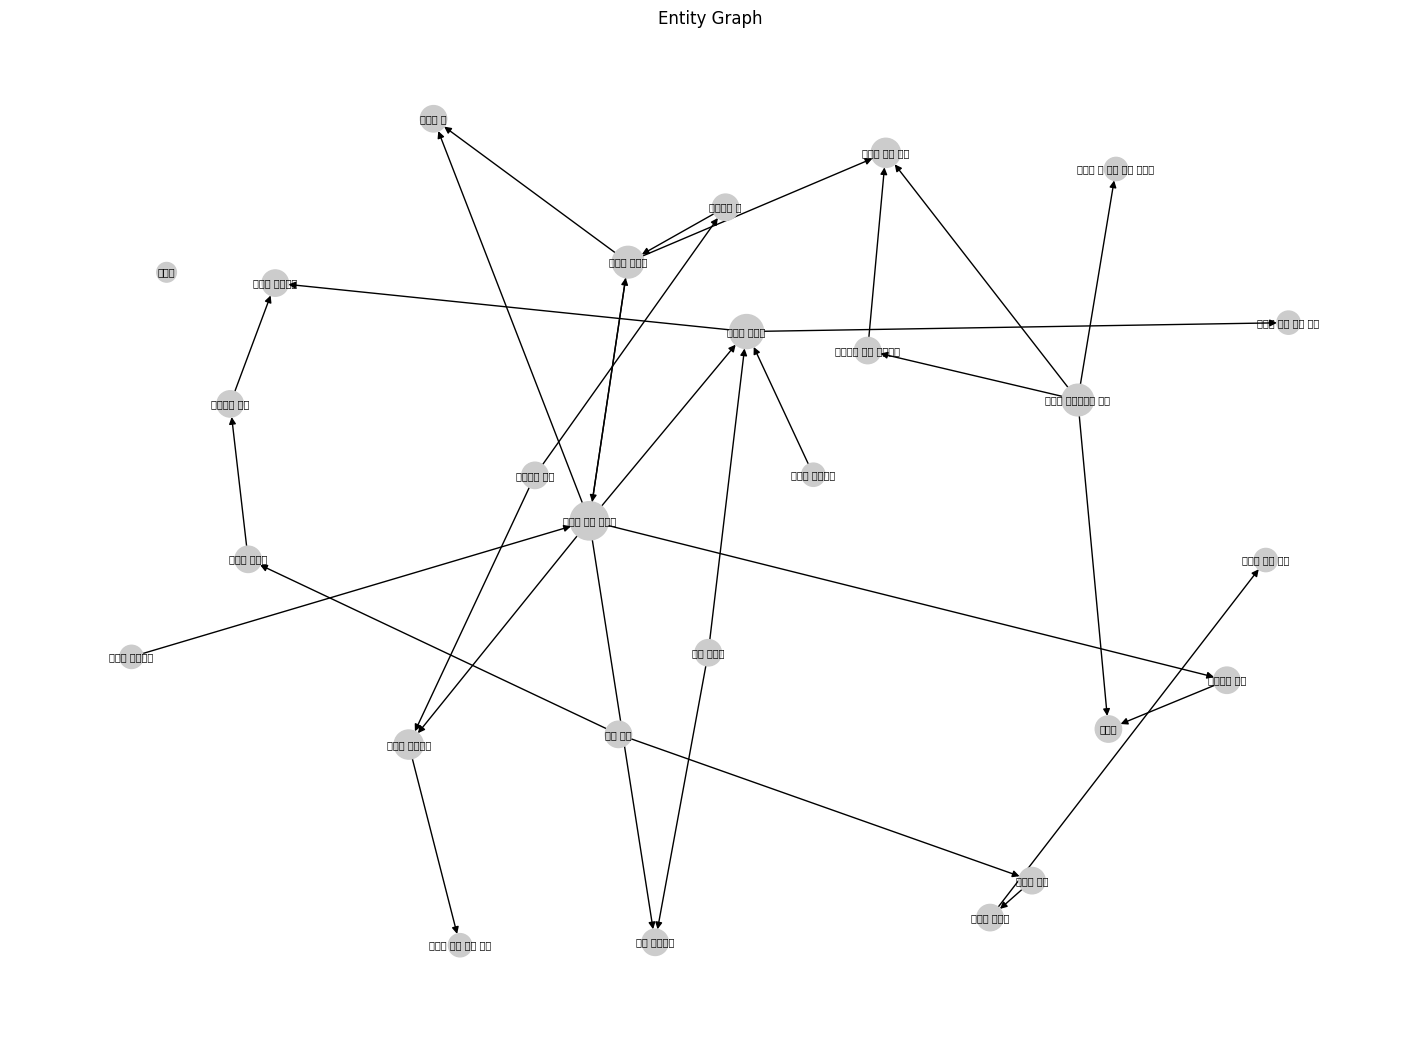

In [85]:
sizes = [200 + 80 * g_ms.nodes[n].get('degree', 1) for n in g_ms.nodes]
# 그리기
plt.figure(figsize=(14, 10))

nx.draw(
    g_ms,
    pos,
    node_color=colors,
    node_size=sizes,
    with_labels=True,
    font_size=7,
    font_family=plt.rcParams.get("font.family", "sans-serif")
)

plt.title("Entity Graph")
plt.show()

In [86]:
comm_df = arts.get('communities')
comm_df

,id,human_readable_id,community,level,parent,children,title,entity_ids,relationship_ids,text_unit_ids,period,size
0,b417fa95-9a7c-41f0-aef0-b9d723629423,0,0,0,-1,[],Community 0,"[f9cb17e1-e964-4aed-9f70-1b2f61c65e34, 946c822...","[0077d0b6-0db0-41bb-9352-3eee0e5ac354, 28dfe7d...",[d7c4b424977cdb56abcd05f89a5ed4e70fc2377a77719...,2026-06-12,6
1,ce7459c9-fb5f-4e7f-bc7e-d6cd0572d910,1,1,0,-1,[],Community 1,"[215238dd-814e-4caa-a0ee-820e1f981329, 0bcef44...","[6c71ab8d-9041-4f97-85ad-af10e92f2fef, 6fa04c8...",[7e9b91faac70c0cf956528a33c95742350d3cc1900869...,2026-06-12,8
2,9e2b2981-529e-49ac-a51c-7a101f0e2b30,2,2,0,-1,[],Community 2,"[e53a7f52-98de-4e8b-aea7-80ef7a2cbf42, d1df8b3...","[20d00c84-930d-4a23-853c-902cfcb0e56f, 7ce4ec6...",[7e9b91faac70c0cf956528a33c95742350d3cc1900869...,2026-06-12,6
3,048a8d7e-9e20-44d6-bb09-9e8f3609bba5,3,3,0,-1,[],Community 3,"[6f8d7a13-befe-446a-98a0-d8056ed2d951, 5438b03...","[0ccfe692-a80b-471d-b8e8-ad6d0099a847, 6426ff9...",[7e9b91faac70c0cf956528a33c95742350d3cc1900869...,2026-06-12,6


In [88]:
def entity_neighbors(arts, name):
  rel = arts['relationships']
  out = []
  for _, row in rel.iterrows():
    if row['source'] == name:
      out.append({'direction' : 'out', 'target' : row['target'], 'desc': str(row.get('description', ''))})
    elif row['target'] == name:
      out.append({'direction' : 'in', 'target' : row['target'], 'desc': str(row.get('description', ''))})

  return out

In [90]:
entity_neighbors(arts, '모리카이 센')

[{'direction': 'out',
  'target': '콰빅스 연구소',
  'desc': '모리카이 센이 1987년에 콰빅스 연구소를 설립했다'},
 {'direction': 'in',
  'target': '모리카이 센',
  'desc': '탈라미르 헤쉬는 모리카이 센의 박사 학위 지도 교수이자 초기 논문 지도 교수였다'}]

In [97]:
!mv "{PROJECT_ROOT}/output/lancedb/entity_description.lance" \
     "{PROJECT_ROOT}/output/lancedb/entity_description"

In [98]:
!graphrag query \
  --root "{PROJECT_ROOT}" \
  --method local \
  "콰빅스 연구소는 무엇이고, 모리카이 센과의 관계는?"

13:05:34 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'
13:05:34 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'
╭───────────────────── Traceback (most recent call last) ──────────────────────╮
│ /usr/local/lib/python3.12/dist-packages/graphrag/cli/main.py:441 in          │
│ _query_cli                                                                   │
│                                                                              │
│   438 │                                                                      │
│   439 │   match method:                                                      │
│   440 │   │   case SearchMethod.LOCAL:                                       │
│ ❱ 441 │   │   │   run_

In [96]:
print(PROJECT_ROOT)

/content/drive/MyDrive/Colab Notebooks/ragtest_0612
